In [17]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [21]:
class Bandit:
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
        self.true_means = np.random.normal(0, 1, n_arms)  # hidden
        self.optimal_arm = np.argmax(self.true_means)

    def pull(self, arm):
        """Return a noisy reward for the chosen arm."""
        return np.random.normal(self.true_means[arm], 1.0)

bandit = Bandit(n_arms=10)
print("True arm means (hidden from agent):", np.round(bandit.true_means, 2))
print(f"Optimal arm: {bandit.optimal_arm} (mean={bandit.true_means[bandit.optimal_arm]:.2f})")

True arm means (hidden from agent): [-0.6   1.85 -0.01 -1.06  0.82 -1.22  0.21 -1.96 -1.33  0.2 ]
Optimal arm: 1 (mean=1.85)


In [23]:
def run_agent(bandit, policy, n_steps=1000):
    n_arms = bandit.n_arms
    Q = np.zeros(n_arms)   # estimated values
    N = np.zeros(n_arms)   # pull counts
    rewards = []
    optimal_actions = []

    for t in range(n_steps):
        arm = policy(Q, N, t)
        reward = bandit.pull(arm)
        N[arm] += 1
        Q[arm] += (reward - Q[arm]) / N[arm]  # incremental mean update
        rewards.append(reward)
        optimal_actions.append(arm == bandit.optimal_arm)

    return np.array(rewards), np.array(optimal_actions)

# --- Policies ---
def greedy(Q, N, t):          return np.argmax(Q)
def epsilon_greedy(eps):      return lambda Q, N, t: np.random.randint(len(Q)) if np.random.rand() < eps else np.argmax(Q)
def ucb(c=2):                 return lambda Q, N, t: np.argmax(Q + c * np.sqrt(np.log(t+1) / (N+1e-9)))
def softmax(tau=0.5):         return lambda Q, N, t: np.random.choice(len(Q), p=(lambda e: e/e.sum())(np.exp((Q - Q.max())/tau)))

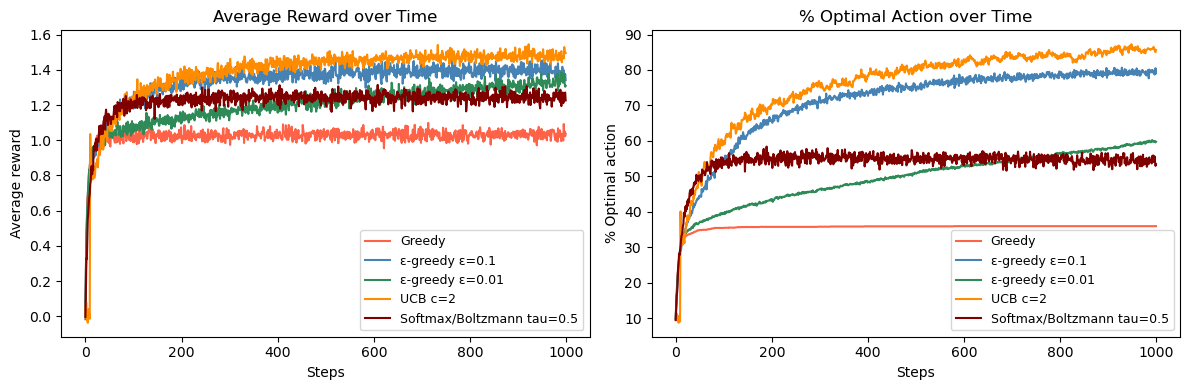

In [26]:
N_RUNS = 2000
N_STEPS = 1000

configs = [
    ('Greedy',                     greedy,                'tomato'),
    ('ε-greedy ε=0.1',             epsilon_greedy(0.1),   'steelblue'),
    ('ε-greedy ε=0.01',            epsilon_greedy(0.01),  'seagreen'),
    ('UCB c=2',                    ucb(2),                'darkorange'),
    ('Softmax/Boltzmann tau=0.5',  softmax(0.5),          'maroon')
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, policy, color in configs:
    all_rewards   = np.zeros((N_RUNS, N_STEPS))
    all_optimal   = np.zeros((N_RUNS, N_STEPS))
    for run in range(N_RUNS):
        b = Bandit(n_arms=10)
        r, opt = run_agent(b, policy, N_STEPS)
        all_rewards[run] = r
        all_optimal[run] = opt
    axes[0].plot(all_rewards.mean(axis=0), label=label, color=color, linewidth=1.5)
    axes[1].plot(all_optimal.mean(axis=0)*100, label=label, color=color, linewidth=1.5)

axes[0].set_xlabel('Steps'); axes[0].set_ylabel('Average reward')
axes[0].set_title('Average Reward over Time'); axes[0].legend(fontsize=9)
axes[1].set_xlabel('Steps'); axes[1].set_ylabel('% Optimal action')
axes[1].set_title('% Optimal Action over Time'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

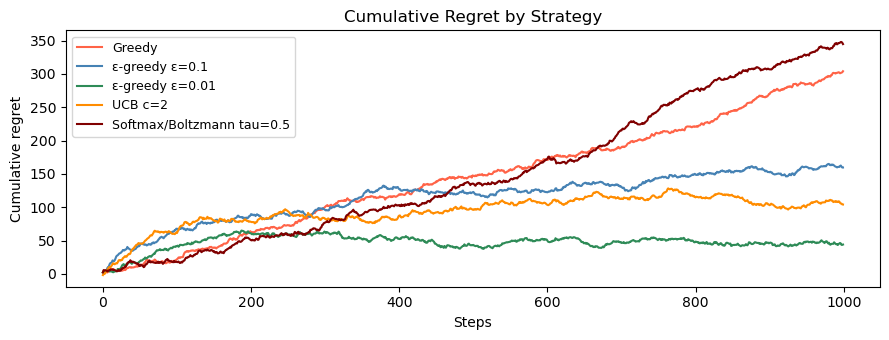

In [25]:
b = Bandit(n_arms=10)
best_mean = b.true_means.max()

plt.figure(figsize=(9, 3.5))
for label, policy, color in configs:
    b = Bandit(n_arms=10)
    # fix the same bandit for fair comparison
    b.true_means = np.array([0.2, -0.5, 1.2, 0.8, -0.1, 0.5, -0.8, 0.3, 1.5, 0.0])
    b.optimal_arm = np.argmax(b.true_means)
    best_mean = b.true_means.max()
    rewards, _ = run_agent(b, policy, N_STEPS)
    cumulative_regret = np.cumsum(best_mean - rewards)
    plt.plot(cumulative_regret, label=label, color=color, linewidth=1.5)
plt.xlabel('Steps'); plt.ylabel('Cumulative regret')
plt.title('Cumulative Regret by Strategy')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()